In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:
# Load data from CSV
csv_path = '/home/apa2237/generative_model_work/datasets/aav/full_data.csv'
df = pd.read_csv(csv_path, low_memory=False)

# Use full_aa_sequence as x and score as y
data = np.array([[row['full_aa_sequence'], row['score']] for _, row in df.iterrows()], dtype=object)

# Make dict of data with sequence as key and score as value
data_dict = {}
for i in range(len(data)):
    key = data[i][0]
    value = data[i][1]
    data_dict[key] = value
np.save('data_dict.npy', data_dict)
np.save('data.npy', data)

print(f"Loaded {len(data)} sequences")
print(f"Example sequence (first 100 chars): {data[0][0][:100]}")
print(f"Example score: {data[0][1]}")

Loaded 284009 sequences
Example sequence (first 100 chars): MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLVLPGYKYLGPFNGLDKGEPVNEADAAALEHDKAYDRQLDSGDNPYLKYNHADAEF
Example score: -6.824780284006794


In [5]:
# Check unique characters in sequences
all_chars = set()
for seq in df['full_aa_sequence']:
    all_chars.update(set(seq))
print(f"Unique characters in sequences: {sorted(all_chars)}")
print(f"Number of unique characters: {len(all_chars)}")

Unique characters in sequences: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
Number of unique characters: 20


In [6]:
# Finding the largest protein sequence
def find_max_len(data):
    max_len = 0
    for i in range(data.shape[0]):
        str_len = len(data[i, 0])
        if max_len < str_len:
            max_len = str_len
    print('Max len is', max_len)
    return max_len

max_len = find_max_len(data)

Max len is 750


In [7]:
# Standard 20 amino acids
amino_acid = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
print('Number of unique amino acids are', len(amino_acid))
np.save('categorical_variables', amino_acid)

def onehotseq(sequence):
    aa_seq = ''
    seq_len = len(sequence)
    seq_en = np.zeros((seq_len, len(amino_acid)))
    act_len = 0
    for i in range(seq_len):
        if sequence[i] in amino_acid:
            pos = amino_acid.index(sequence[i])
            seq_en[act_len, pos] = 1
            act_len += 1  
            aa_seq += sequence[i]    
    return seq_en[0:act_len, :], aa_seq

Number of unique amino acids are 20


In [8]:
# One-hot encode all sequences
ohe = np.zeros((data.shape[0], max_len, len(amino_acid)))  # batch_size x sequence_len x 20
seq_string = np.zeros((data.shape[0],), dtype=object)  # store string sequences
seq_lengths = np.zeros((data.shape[0],))
scores = np.zeros((data.shape[0], 1))

for i in range(ohe.shape[0]):
    if i % 50000 == 0:
        print(f"Processing {i}/{ohe.shape[0]}")
    seq_en, aa_seq = onehotseq(data[i, 0])
    seq_string[i] = aa_seq
    ohe[i, 0:seq_en.shape[0], :] = seq_en
    seq_lengths[i] = seq_en.shape[0]
    scores[i, 0] = data[i, 1]

# Normalize scores to [0, 1]
score_min = scores.min()
score_max = scores.max()
output_y = (scores - score_min) / (score_max - score_min)
seq_length = seq_lengths

print(f"\nTotal samples: {len(ohe)}")
print(f"Example sequence: {seq_string[0][:50]}...")
print(f"Sequence length: {seq_length[0]}")
print(f"One-hot shape: {ohe.shape}")
print(f"Score range: [{score_min}, {score_max}] -> normalized to [0, 1]")

Processing 0/284009
Processing 50000/284009
Processing 100000/284009
Processing 150000/284009
Processing 200000/284009
Processing 250000/284009

Total samples: 284009
Example sequence: MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLVLPGY...
Sequence length: 735.0
One-hot shape: (284009, 750, 20)
Score range: [-11.176109295334715, 9.53645667061] -> normalized to [0, 1]


In [9]:
# Randomly select subsets: 5000 train, 500 valid, 500 test
np.random.seed(42)

# Get all valid indices
all_idx = np.arange(len(df))

# Randomly shuffle and select
np.random.shuffle(all_idx)

x_train = all_idx[:5000]
x_valid = all_idx[5000:5500]
x_test = all_idx[5500:6000]

print(f'Train: {len(x_train)}')
print(f'Test: {len(x_test)}')
print(f'Valid: {len(x_valid)}')
print(f'OHE shape: {ohe[x_train].shape}, Length shape: {seq_length[x_train].shape}, Y shape: {output_y[x_train].shape}')

Train: 5000
Test: 500
Valid: 500
OHE shape: (5000, 750, 20), Length shape: (5000,), Y shape: (5000, 1)


In [10]:
np.save('./x_train', ohe[x_train])
np.save('./len_train', seq_length[x_train])
np.save('./y_train', output_y[x_train])
np.save('./seq_train', seq_string[x_train])

np.save('./x_valid', ohe[x_valid])
np.save('./len_valid', seq_length[x_valid])
np.save('./y_valid', output_y[x_valid])
np.save('./seq_valid', seq_string[x_valid])

np.save('./x_test', ohe[x_test])
np.save('./len_test', seq_length[x_test])
np.save('./y_test', output_y[x_test])
np.save('./seq_test', seq_string[x_test])

print("Data files saved successfully!")
print(f"x_train shape: {ohe[x_train].shape}")
print(f"x_valid shape: {ohe[x_valid].shape}")
print(f"x_test shape: {ohe[x_test].shape}")

Data files saved successfully!
x_train shape: (5000, 750, 20)
x_valid shape: (500, 750, 20)
x_test shape: (500, 750, 20)


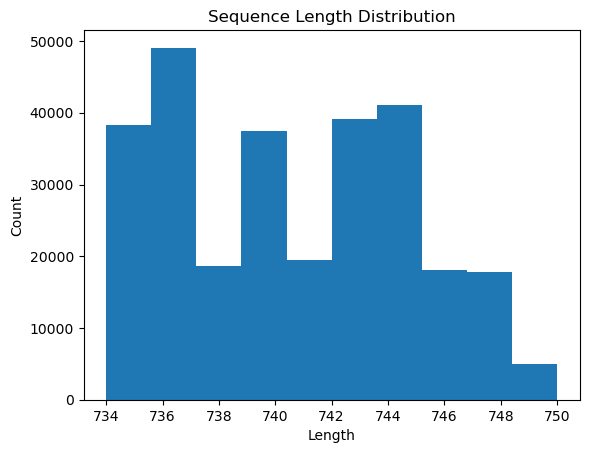

In [11]:
plt.hist(seq_length)
plt.title('Sequence Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

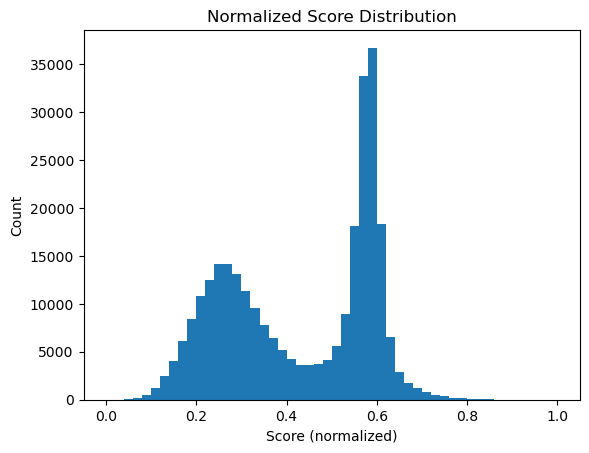

In [12]:
plt.hist(output_y, bins=50)
plt.title('Normalized Score Distribution')
plt.xlabel('Score (normalized)')
plt.ylabel('Count')
plt.show()